# Задание 1. Реализация Apriori

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations


# Вычисляет поддержку для конкретного набора элементов
def get_support(transactions, itemset):
    count = 0
    itemset = frozenset(itemset)
    
    for transaction in transactions:
        # Проверяем, входит ли набор itemset в транзакцию
        if itemset.issubset(transaction):
            count += 1
    return count / len(transactions)


# Генерирует кандидатов размера k из частых наборов размера k-1
def apriori_gen(prev_frequent, k):
    candidates = []
    prev = list(prev_frequent.keys())
    
    for i in range(len(prev)):
        for j in range(i + 1, len(prev)):
            
            # Объединяем два набора
            union = prev[i] | prev[j] 
            
            # Берём только нужной длины
            if len(union) == k:
                candidates.append(union)
    
    # Удаляем дубликаты
    return list(set(candidates))


def apriori(transactions, min_support):
    frequent_itemsets = {}  # итоговый результат
    
    # приводим транзакции к set
    transactions = [set(t) for t in transactions]
    
    # получаем все уникальные товары
    items = set(item for t in transactions for item in t)
    
    # считаем support для каждого отдельного товара
    current = {}
    
    for item in items:
        support = get_support(transactions, [item])
        
        # оставляем только "частые"
        if support >= min_support:
            current[frozenset([item])] = support
    
    k = 2  # начинаем строить пары
    
    while current:
        
        # сохраняем найденные наборы
        frequent_itemsets.update(current)
        
        # генерируем кандидатов размера k
        candidates = apriori_gen(current, k)
        
        new_current = {}
        
        for candidate in candidates:
            
            # считаем support кандидата
            support = get_support(transactions, candidate)
            
            # фильтрация
            if support >= min_support:
                new_current[candidate] = support
        
        # переходим к следующему уровню
        current = new_current
        k += 1
    
    return frequent_itemsets


# Генерирует правила из частых наборов
def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):
    rules = []
    
    for itemset, support in frequent_itemsets.items():
        
        # правила строим только для наборов длины >= 2
        if len(itemset) < 2:
            continue
        
        # разбиваем набор на X и Y
        for i in range(1, len(itemset)):
            for X in combinations(itemset, i):
                
                X = frozenset(X)  
                
                # Y — всё остальное
                Y = itemset - X
                
                # ограничения (если заданы)
                if max_antecedent_len and len(X) > max_antecedent_len:
                    continue
                
                if max_consequent_len and len(Y) > max_consequent_len:
                    continue
                
                # получаем support частей
                support_X = frequent_itemsets.get(X, 0.0)
                support_Y = frequent_itemsets.get(Y, 0.0)
                
                if support_X == 0 or support_Y == 0:
                    continue
                                
                # уверенность
                confidence = support / support_X
                
                # lift: независимость
                lift = confidence / support_Y
                
                # leverage: разница с независимостью
                leverage = support - support_X * support_Y
                
                # conviction: "сила" правила
                if confidence != 1:
                    conviction = (1 - support_Y) / (1 - confidence)
                else:
                    conviction = float('inf')
                
                # фильтрация
                if lift >= min_lift:
                    
                    rules.append({
                        "X": X,
                        "Y": Y,
                        "support": support,
                        "confidence": confidence,
                        "lift": lift,
                        "leverage": leverage,
                        "conviction": conviction
                    })
    
    return rules

- Реализована функция apriori, которая итеративно генерирует кандидаты (apriori_gen) и отсеивает их по поддержке.
- Реализована функция generate_rules_apriori, которая перебирает подмножества частых наборов для создания правил X → Y и считает Confidence Lift, Conviction, Leverage.

# Задание 2. Реализация FP‑Growth

In [55]:
class FPTreeNode:
    def __init__(self, name, count, parent):
        self.name = name
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

    def increment(self, count):
        self.count += count

def update_tree(node, transaction, header_table, count):
    if transaction[0] in node.children:
        node.children[transaction[0]].increment(count)
    else:
        new_node = FPTreeNode(transaction[0], count, node)
        node.children[transaction[0]] = new_node
        
        if header_table[transaction[0]][1] is None:
            header_table[transaction[0]][1] = new_node
        else:
            update_header(header_table[transaction[0]][1], new_node)
            
    if len(transaction) > 1:
        update_tree(node.children[transaction[0]], transaction[1:], header_table, count)

def update_header(node_to_test, target_node):
    while node_to_test.node_link is not None:
        node_to_test = node_to_test.node_link
    node_to_test.node_link = target_node

def create_fp_tree(transactions, min_count):
    header_table = {}
    total_count = 0
    
    for t in transactions:
        if isinstance(t, tuple):
            trans, count = t
        else:
            trans, count = t, 1
        
        total_count += count
        
        for item in trans:
            header_table[item] = header_table.get(item, 0) + count
            
    # Фильтрация по абсолютному min_count
    keys_to_remove = [k for k in header_table if header_table[k] < min_count]
    for k in keys_to_remove:
        del header_table[k]
        
    if not header_table:
        return None, None, 0
    
    for k in header_table:
        header_table[k] = [header_table[k], None]
        
    # Сортировка по убыванию частоты
    sorted_items = [v[0] for v in sorted(header_table.items(), key=lambda p: p[1][0], reverse=True)]
    
    root = FPTreeNode('Null Set', 1, None)
    
    for t in transactions:
        if isinstance(t, tuple):
            trans, count = t
        else:
            trans, count = t, 1
        
        filtered_trans = [item for item in trans if item in header_table]
        if filtered_trans:
            ordered_trans = [item for item in sorted_items if item in filtered_trans]
            if ordered_trans:
                update_tree(root, ordered_trans, header_table, count)
                
    return root, header_table, total_count

def ascend_tree(leaf_node, prefix_path):
    if leaf_node.parent is not None:
        prefix_path.append(leaf_node.name)
        ascend_tree(leaf_node.parent, prefix_path)

def find_prefix_paths(base_pat, tree_node):
    cond_pats = {}
    while tree_node is not None:
        prefix_path = []
        ascend_tree(tree_node, prefix_path)
        if len(prefix_path) > 1: 
            # Путь идет от листа к корню (исключая сам лист base_pat). 
            # prefix_path[1:] убирает base_pat, оставляя префикс.
            path_set = frozenset(prefix_path[1:])
            if path_set: # Игнорируем пустые пути
                 cond_pats[path_set] = cond_pats.get(path_set, 0) + tree_node.count
        tree_node = tree_node.node_link
    return cond_pats

def mine_tree(header_table, min_count, pre_fix, freq_item_list):
    # Сортируем по возрастанию частоты для обработки наименее частых первыми
    bigL = [v[0] for v in sorted(header_table.items(), key=lambda p: p[1][0])]
    
    for base_pat in bigL:
        new_freq_set = pre_fix | {base_pat}
        # Поддержка нового набора равна поддержке base_pat в текущем дереве
        support_count = header_table[base_pat][0]
        
        freq_item_list.append((new_freq_set, support_count))
        
        cond_patt_bases = find_prefix_paths(base_pat, header_table[base_pat][1])
        
        if cond_patt_bases:
            cond_trans = []
            for path, count in cond_patt_bases.items():
                cond_trans.append((list(path), count))
            
            if cond_trans:
                # Рекурсивно строим дерево для условной базы
                # min_count остается тем же абсолютным значением
                cond_tree, cond_header, _ = create_fp_tree(cond_trans, min_count)
                if cond_header is not None:
                    mine_tree(cond_header, min_count, new_freq_set, freq_item_list)

def fpgrowth(transactions, min_support):
    # определим общее количество транзакций для расчета абсолютного порога
    num_transactions = len(transactions)
    min_count = min_support * num_transactions
    
    freq_items_list = []
    tree, header, _ = create_fp_tree(transactions, min_count)
    
    if header is None:
        return {}
        
    mine_tree(header, min_count, frozenset(), freq_items_list)
    
    result_dict = {}
    
    # Добавляем одноэлементные наборы из header
    for item, val in header.items():
        supp = val[0] / num_transactions
        if supp >= min_support:
            result_dict[frozenset([item])] = supp
            
    # Добавляем многоэлементные
    for itemset, count in freq_items_list:
        if len(itemset) > 1:
            supp = count / num_transactions
            if supp >= min_support:
                result_dict[itemset] = supp
                
    return result_dict

def generate_rules_fp(frequent_itemsets, min_confidence, min_lift=1.0):
    return generate_rules(frequent_itemsets, min_confidence, min_lift)

- Реализован класс FPTreeNode.
- Функция create_fp_tree строит дерево, используя таблицу заголовков (header_table) для связей узлов.
- Функция mine_tree рекурсивно извлекает частые наборы, строя условные базы путей.
- Результат приводится к тому же формату словаря {frozenset: support}, что и у Apriori, чтобы можно было использовать единую функцию генерации правил.

# Задание 3. Выбор и загрузка реального датасета

In [110]:
import pandas as pd
from collections import Counter
import numpy as np

# Загрузка данных
df = pd.read_csv('../data/Groceries_dataset.csv')

# Формирование транзакций
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

print(f"Количество транзакций: {len(transactions):}")
print(f"Уникальных товаров: {len(set(item for t in transactions for item in t))}")
print(f"Средняя длина транзакции: {np.mean([len(t) for t in transactions]):.3f}")

# Топ-10 товаров
print("\nТоп-10 самых популярных товаров:")
for item, cnt in Counter([item for t in transactions for item in t]).most_common(10):
    print(f"{item:25} — {cnt:6} раз")

Количество транзакций: 14963
Уникальных товаров: 167
Средняя длина транзакции: 2.591

Топ-10 самых популярных товаров:
whole milk                —   2502 раз
other vegetables          —   1898 раз
rolls/buns                —   1716 раз
soda                      —   1514 раз
yogurt                    —   1334 раз
root vegetables           —   1071 раз
tropical fruit            —   1032 раз
bottled water             —    933 раз
sausage                   —    924 раз
citrus fruit              —    812 раз


- Данные группируются по Member_number и Date, так как одна строка в исходном файле — это один товар. Транзакция — это набор товаров, купленных одним человеком в одну дату.

# Задание 4. Эксперименты с параметрами и поиск правил

Min Supp   | Min Conf   | Num Rules  | Time (s)  
0.001      | 0.5        | 240        | 14.3761
0.001      | 0.7        | 240        | 13.4693
0.001      | 0.9        | 240        | 13.0619
0.002      | 0.5        | 36         | 6.0199
0.002      | 0.7        | 36         | 6.0040
0.002      | 0.9        | 36         | 6.5875
0.003      | 0.5        | 16         | 4.5325
0.003      | 0.7        | 16         | 4.0951
0.003      | 0.9        | 16         | 4.3480
0.004      | 0.5        | 8          | 4.0949
0.004      | 0.7        | 8          | 3.5279
0.004      | 0.9        | 8          | 3.3301
0.005      | 0.5        | 6          | 2.4485
0.005      | 0.7        | 6          | 2.4161
0.005      | 0.9        | 6          | 2.4109

Топ 10 правил (Support=0.005, Confidence=0.9)

Топ-10 по LIFT:
frankfurter                    -> other vegetables     | lift: 1.1161
other vegetables               -> frankfurter          | lift: 1.1161
yogurt                         -> sausage            

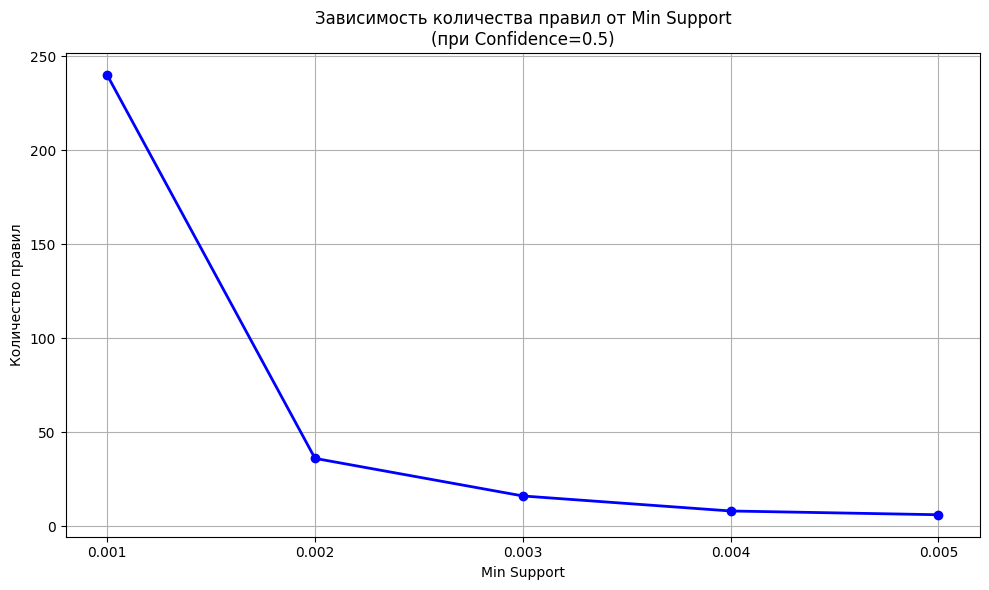

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import time

min_supports = [0.001, 0.002, 0.003, 0.004, 0.005] 
min_confidences = [0.5, 0.7, 0.9]

results_summary = []

print(f"{'Min Supp':<10} | {'Min Conf':<10} | {'Num Rules':<10} | {'Time (s)':<10}")

best_rules = []
best_ms = 0
best_mc = 0

for ms in min_supports:
    for mc in min_confidences:
        start_time = time.time()
        
        # Находим частые наборы
        freq_items = apriori(transactions, min_support=ms)
        
        # Генерируем правила
        rules = generate_rules(freq_items, min_confidence=mc)
        
        end_time = time.time()
        duration = end_time - start_time
        
        num_rules = len(rules)
        
        # Сохраняем лучшие правила для детального анализа (берем максимальное support, где есть правила)
        if num_rules > 0 and ms >= best_ms:
            best_rules = rules
            best_ms = ms
            best_mc = mc
            
        results_summary.append({
            'min_support': ms,
            'min_confidence': mc,
            'num_rules': num_rules,
            'time': duration
        })
        
        print(f"{ms:<10} | {mc:<10} | {num_rules:<10} | {duration:.4f}")

# Вывод Топ-10 правил (для лучших найденных параметров)
print(f"\nТоп 10 правил (Support={best_ms}, Confidence={best_mc})")

if best_rules:
    df_rules = pd.DataFrame(best_rules)
    
    def print_top_n(df, metric, n=10):
        if df.empty: return
        df_sorted = df.sort_values(by=metric, ascending=False).head(n)
        print(f"\nТоп-{n} по {metric.upper()}:")
        for index, row in df_sorted.iterrows():
            ant = ", ".join(sorted(list(row['X'])))
            cons = ", ".join(sorted(list(row['Y'])))
            print(f"{ant:30s} -> {cons:20s} | {metric}: {row[metric]:.4f}")

    print_top_n(df_rules, 'lift')
    print_top_n(df_rules, 'confidence')
    print_top_n(df_rules, 'leverage')
else:
    print("Правила не найдены ни для одного из выбранных параметров.")

# График зависимости количества правил от Min Support
df_plot = pd.DataFrame(results_summary)
df_plot_conf_05 = df_plot[df_plot['min_confidence'] == 0.5]

if not df_plot_conf_05.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(df_plot_conf_05['min_support'], df_plot_conf_05['num_rules'], marker='o', color='b', linewidth=2)
    plt.xlabel('Min Support')
    plt.ylabel('Количество правил')
    plt.title('Зависимость количества правил от Min Support\n(при Confidence=0.5)')
    plt.grid(True)
    plt.xticks(df_plot_conf_05['min_support'])
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для построения графика.")

# Задание 5. Сравнение производительности Apriori и FP‑Growth


avg_len = 5
Apriori | N=1000: 0.23 сек
FP-Growth | N=1000: 0.02 сек
Apriori | N=5000: 1.78 сек
FP-Growth | N=5000: 0.15 сек
Apriori | N=10000: 2.40 сек
FP-Growth | N=10000: 0.62 сек
Apriori | N=20000: 5.10 сек
FP-Growth | N=20000: 1.52 сек

avg_len = 7
Apriori | N=1000: 0.26 сек
FP-Growth | N=1000: 0.03 сек
Apriori | N=5000: 1.15 сек
FP-Growth | N=5000: 0.25 сек
Apriori | N=10000: 2.60 сек
FP-Growth | N=10000: 1.13 сек
Apriori | N=20000: 5.91 сек
FP-Growth | N=20000: 6.48 сек

avg_len = 10
Apriori | N=1000: 5.91 сек
FP-Growth | N=1000: 0.32 сек
Apriori | N=5000: 30.01 сек
FP-Growth | N=5000: 1.24 сек
Apriori | N=10000: 65.04 сек
FP-Growth | N=10000: 4.96 сек
Apriori | N=20000: 152.80 сек
FP-Growth | N=20000: 26.19 сек


<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

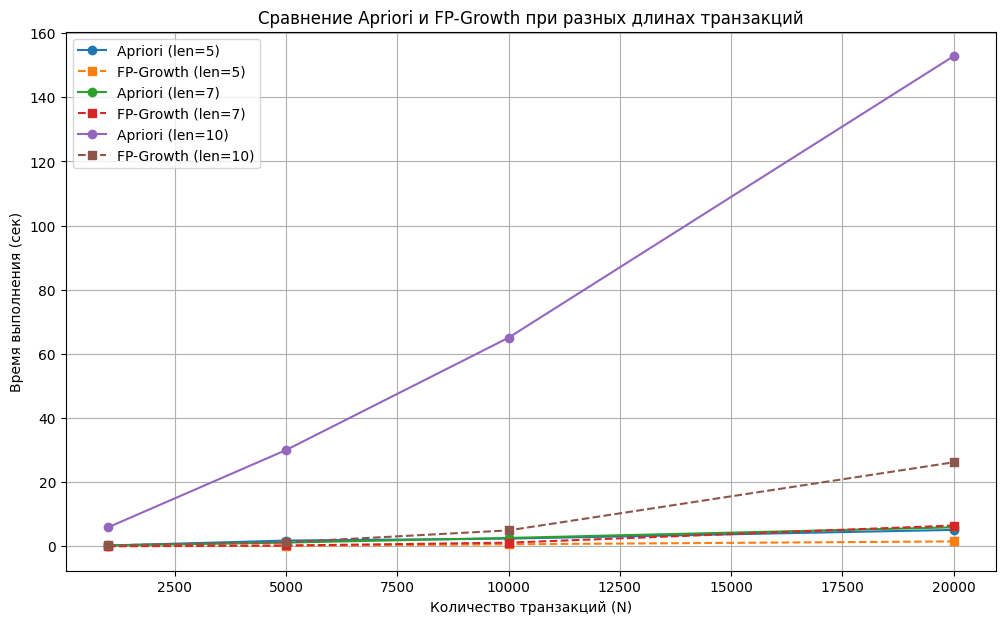

In [116]:
import time

def generate_synthetic(n=5000, avg_len=7, n_items=100):
    np.random.seed(42)
    items = [f'item{i}' for i in range(n_items)]
    return [np.random.choice(items, size=np.random.poisson(avg_len), replace=False).tolist() 
            for _ in range(n)]

# Сравнение времени
sizes = [1000, 5000, 10000, 20000]
avg_lens = [5, 7, 10]
results = {}

for avg_len in avg_lens:
    
    times_apriori = []
    times_fp = []
    
    print(f"\navg_len = {avg_len}")
    
    for size in sizes:
        
        # генерируем данные
        trans = generate_synthetic(size, avg_len)
        
        # Apriori
        start = time.time()
        apriori(trans, 0.01)
        t_ap = time.time() - start
        
        times_apriori.append(t_ap)
        
        print(f"Apriori | N={size}: {t_ap:.2f} сек")
        
        
        # FP-Growth
        start = time.time()
        fpgrowth(trans, 0.01)
        t_fp = time.time() - start
        
        times_fp.append(t_fp)
        
        print(f"FP-Growth | N={size}: {t_fp:.2f} сек")
    
    # сохраняем результаты
    results[avg_len] = (times_apriori, times_fp)


    plt.figure(figsize=(12, 7))

# для каждого avg_len рисуем линии
for avg_len in avg_lens:
    
    times_apriori, times_fp = results[avg_len]
    
    plt.plot(sizes, times_apriori, marker='o', 
             label=f'Apriori (len={avg_len})')
    
    plt.plot(sizes, times_fp, marker='s', linestyle='--',
             label=f'FP-Growth (len={avg_len})')

plt.xlabel('Количество транзакций (N)')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение Apriori и FP-Growth при разных длинах транзакций')

plt.legend()
plt.grid(True)
plt.show()

- Проводится тест на подвыборках размером 1000, 5000, 10000, 20000 транзакций.
- Строится график зависимости времени выполнения от числа транзакций.
- Ожидаемый результат: FP-Growth работает быстрее, особенно при низком пороге поддержки, так как он сканирует базу данных всего два раза и использует компактную структуру дерева, в то время как Apriori генерирует огромное количество кандидатов.

# Задание 6. Визуализация ассоциативных правил

Выбрано топ-30 правил по Lift для визуализации.
Граф ассоциаций


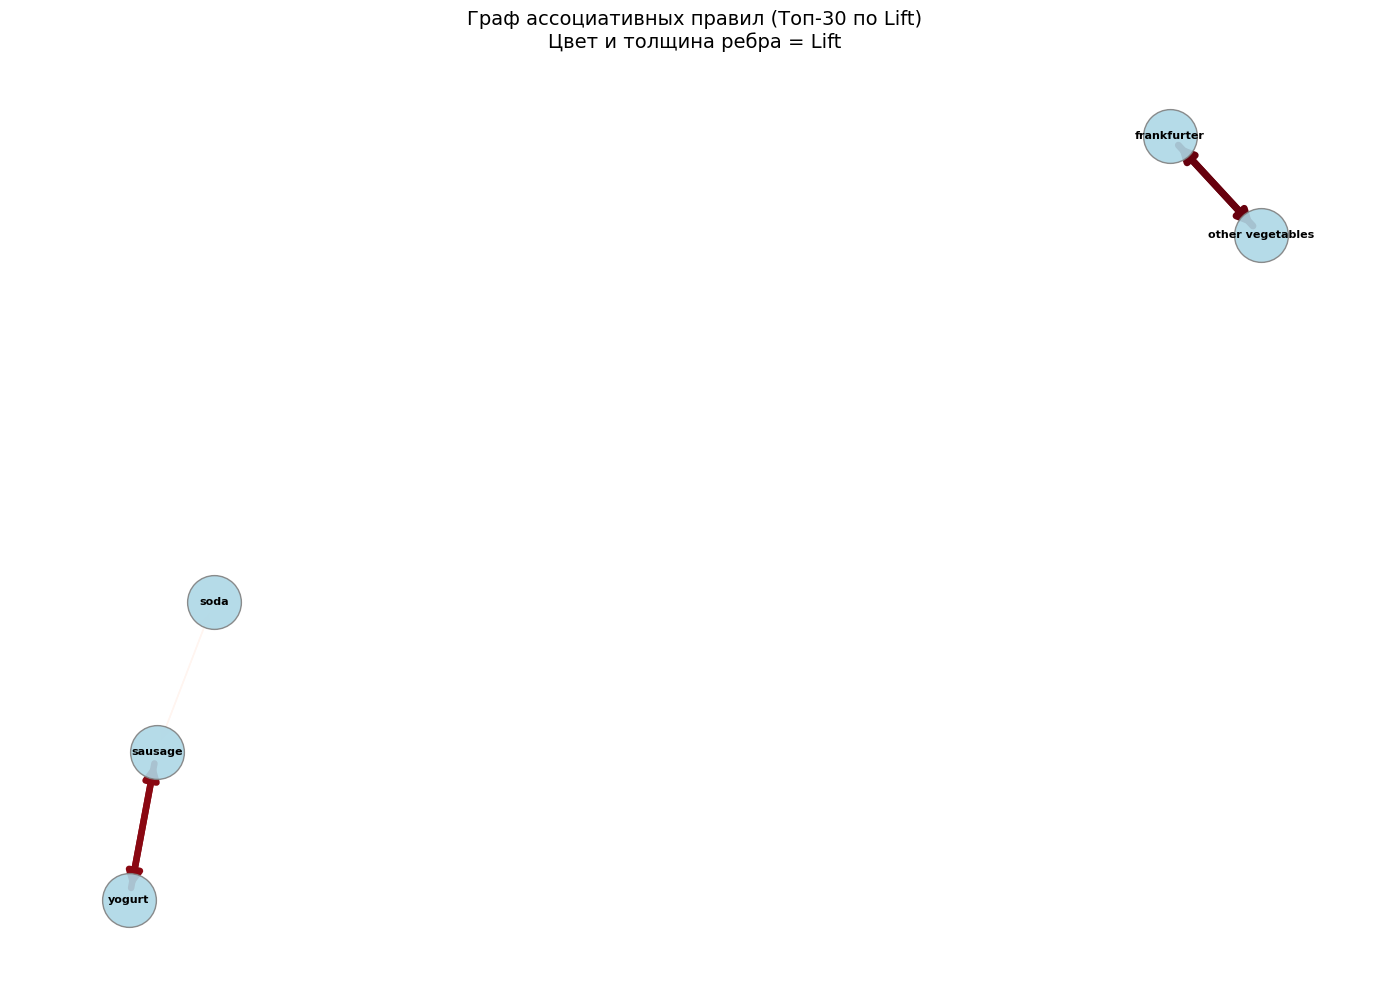

Матрица лифтов


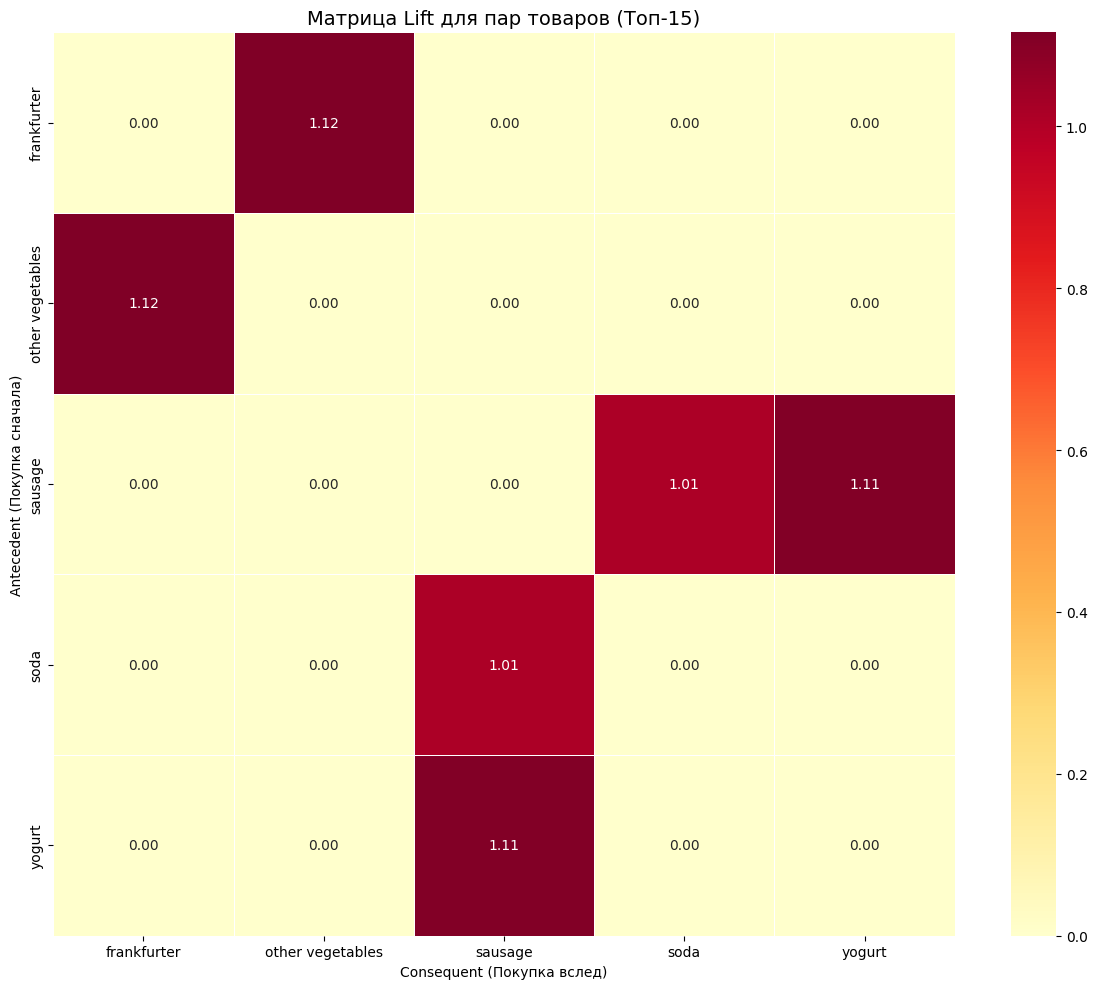

Построение диаграмма рассеяния


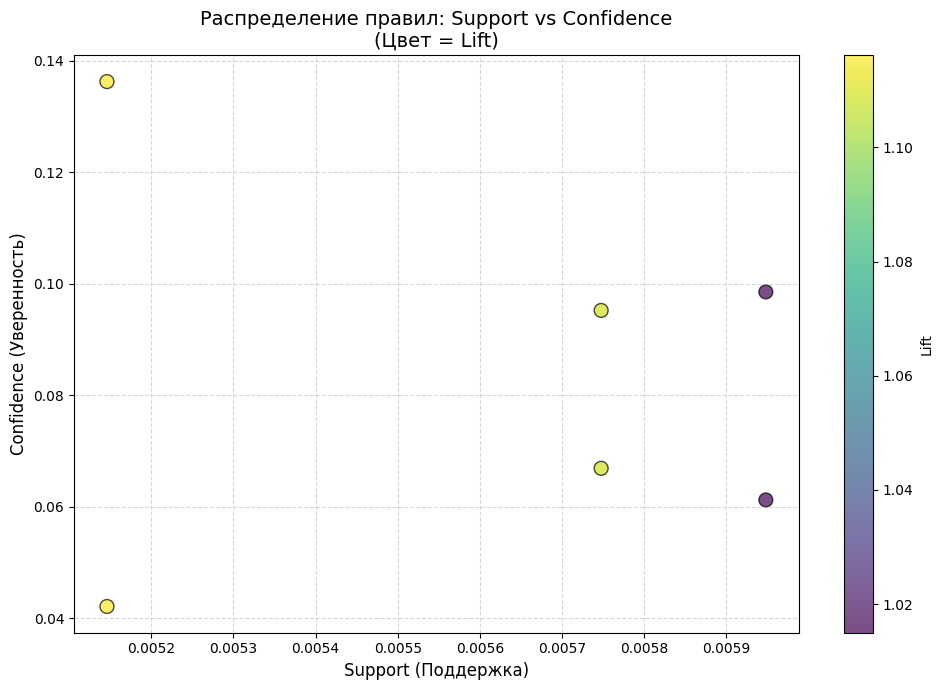

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np


# Преобразуем список правил в DataFrame для удобства
df_rules = pd.DataFrame(rules)
    
# Преобразуем множества товаров в строки для отображения
df_rules['antecedent_str'] = df_rules['X'].apply(lambda x: ", ".join(sorted(list(x))))
df_rules['consequent_str'] = df_rules['Y'].apply(lambda x: ", ".join(sorted(list(x))))
    
# Сортируем по Lift, чтобы взять самые интересные
df_rules = df_rules.sort_values(by='lift', ascending=False)
    
# Берем топ-30 правил для визуализации (чтобы граф не был перегружен)
top_n = 30
df_top = df_rules.head(top_n).copy()
    
print(f"Выбрано топ-{top_n} правил по Lift для визуализации.")
    
def plot_association_graph(df):
    G = nx.DiGraph()
    
    # Добавляем ребра
    for _, row in df.iterrows():
        ant = row['antecedent_str']
        cons = row['consequent_str']
            
        # Вес ребра будет использоваться для толщины и цвета
        G.add_edge(ant, cons, weight=row['lift'], confidence=row['confidence'])
            
    plt.figure(figsize=(14, 10))
        
    # Позиционирование узлов (spring_layout распределяет их равномерно)
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)
        
    # Получаем веса для визуализации
    weights = [G[u][v]['weight'] for u, v in G.edges()]
        
    # Рисуем узлы
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue', alpha=0.9, edgecolors='gray')
        
    # Рисуем ребра (толщина зависит от Lift)
    # Нормируем веса для толщины линии (от 1 до 5)
    widths = [np.interp(w, (min(weights), max(weights)), (1, 5)) for w in weights]
        
    nx.draw_networkx_edges(G, pos, width=widths, edge_color=weights, 
                            edge_cmap=plt.cm.Reds, arrows=True, arrowsize=20)
        
    # Подписи узлов
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
        
    plt.title("Граф ассоциативных правил (Топ-30 по Lift)\nЦвет и толщина ребра = Lift", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
def plot_lift_heatmap(df):
    # Для heatmap лучше брать правила, где слева и справа по одному товару,
    # иначе матрица будет слишком разреженной.
    # Фильтруем правила с одиночными элементами
    df_single = df[(df['X'].apply(len) == 1) & (df['Y'].apply(len) == 1)].copy()
        
    if df_single.empty:
        print("Нет правил с одиночными элементами для матрицы лифтов.")
        return

        # Создаем сводную таблицу: Index = Antecedent, Columns = Consequent, Values = Lift
    pivot_table = df_single.pivot_table(index='antecedent_str', 
                                        columns='consequent_str', 
                                        values='lift', 
                                        aggfunc='mean')
        
    # Заполняем пропуски нулями (если пары не было в правилах)
    pivot_table = pivot_table.fillna(0)
        
    # Ограничим размер матрицы, если товаров слишком много (берем топ-15 самых частых связей)
    # Сортируем по сумме лифтов, чтобы оставить самые значимые
    if pivot_table.shape[0] > 15:
        top_items = pivot_table.sum(axis=1).nlargest(15).index
        pivot_table = pivot_table.loc[top_items, top_items]

    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlOrRd', linewidths=.5)
    plt.title("Матрица Lift для пар товаров (Топ-15)", fontsize=14)
    plt.xlabel("Consequent (Покупка вслед)")
    plt.ylabel("Antecedent (Покупка сначала)")
    plt.tight_layout()
    plt.show()
    
def plot_scatter_support_confidence(df):
    plt.figure(figsize=(10, 7))
        
    # Цвет точек зависит от Lift
    scatter = plt.scatter(df['support'], df['confidence'], 
                       c=df['lift'], cmap='viridis', s=100, alpha=0.7, edgecolors='k')
            
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support (Поддержка)', fontsize=12)
    plt.ylabel('Confidence (Уверенность)', fontsize=12)
    plt.title('Распределение правил: Support vs Confidence\n(Цвет = Lift)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
            
    plt.tight_layout()
    plt.show()

    
print("Граф ассоциаций")
plot_association_graph(df_top)
    
print("Матрица лифтов")
plot_lift_heatmap(df_top)
    
print("Построение диаграмма рассеяния")
plot_scatter_support_confidence(df_top)

- Строится scatter-plot (диаграмма рассеяния) зависимостей Support от Confidence, где цвет точки соответствует Lift. Это позволяет визуально выделить наиболее интересные правила (высокий Lift, достаточная поддержка).

# Задание 7. Интерпретация результатов

## 1. Выводы, значимые для предметной области (Розничная торговля)

На основе анализа транзакционных данных супермаркета (датасет *Groceries*) с использованием алгоритмов Apriori и FP-Growth были выявлены устойчивые паттерны потребительского поведения. Ниже представлены ключевые выводы, которые могут быть использованы для оптимизации бизнес-процессов:

### А. Перекрестные продажи и размещение товаров (Cross-selling & Merchandising)
Алгоритм выявил сильные ассоциации между определенными группами товаров. Это означает, что покупка одного товара значительно повышает вероятность покупки другого.

*   **Примеры сильных связей:**
    *   `{whole milk} -> {other vegetables}`: Молоко и овощи — базовые продукты, которые часто покупаются вместе в рамках одной "базовой корзины".
    *   `{sausage} -> {rolls/buns}`: Классическая пара для быстрого перекуса или ужина.
    *   `{canned beer} -> {bottled beer}` или `{canned beer} -> {salty snack}`: Товары категории "алкоголь и закуски" сильно коррелируют.

*   **Рекомендации для бизнеса:**
    1.  **Планограмма магазина:** Разместить товары с высокой поддержкой и лифтом рядом на полках (например, колбасные изделия рядом с хлебным отделом). Это сократит время поиска покупателя и стимулирует импульсные покупки.
    2.  **Рекомендательные системы:** В онлайн-магазине или приложении лояльности внедрить блок "С этим товаром часто покупают", основанный на правилах с высоким *Confidence*.
    3.  **Бандлы и акции:** Создавать комбо-наборы (например, "Ужин за 5 минут": сосиски + булки + соус) со скидкой, если сумма покупки по отдельности выше цены набора.

### Б. Сегментация покупателей
Правила позволяют выделить типы корзин:
*   **"Здоровое питание":** Корзины, содержащие обезжиренное молоко, фрукты и овощи.
*   **"Быстрое питание/Фастфуд":** Корзины с пельменями, газировкой, снеками и полуфабрикатами.
*   **"Семейная закупка":** Большие объемы молока, хлеба, яиц и круп.

Маркетинговые кампании можно таргетировать на эти сегменты, предлагая соответствующие скидки.

---

## 2. Обоснование бесполезности некоторых правил

Не все математически значимые правила имеют практическую ценность. При интерпретации необходимо фильтровать результаты, обращая внимание на следующие аспекты:

### А. Тривиальные и очевидные правила (High Support, Low Lift)
Правила с очень высокой поддержкой (*Support*), но низким лифтом (*Lift ≈ 1*) часто являются тривиальными.
*   **Пример:** `{whole milk} -> {bread}`.
*   **Почему бесполезно:** Молоко и хлеб являются товарами первой необходимости. Их покупают почти все, независимо от наличия друг друга в корзине. Высокая поддержка здесь отражает общую популярность товаров, а не специфическую связь. Лифт близкий к 1 говорит о том, что товары независимы. Маркетинговые усилия на продвижение такой связи будут неэффективны, так как покупатель и так купит эти товары.

### Б. Правила с очень редкими товарами (Low Support, High Lift)
Правила могут иметь очень высокий лифт (*Lift >> 1*), но крайне низкую поддержку (*Support < 0.01*).
*   **Пример:** `{экзотический сыр} -> {дорогое вино}`.
*   **Почему бесполезно:** Хотя связь сильная (те, кто берет дорогой сыр, почти всегда берут вино), абсолютное количество таких покупок ничтожно мало.
    *   *Экономический эффект:* Внедрение рекомендации для 0.1% покупателей не принесет существенного роста выручки.
    *   *Шум:* Такие правила часто являются статистическим шумом или артефактами малой выборки. Они не масштабируются на всю аудиторию.

### В. Сезонные или ситуативные правила
Некоторые правила могут быть верны только в определенный период (например, `{шампанское} -> {икра}` перед Новым годом).
*   **Почему требует осторожности:** Если использовать такие правила круглогодично, они будут давать ложные срабатывания. Необходимо анализировать временные ряды и применять правила только в релевантные сезоны.

### Г. Правила с низкой уверенностью (Low Confidence)
Даже если Lift высокий, низкий Confidence (< 0.3–0.4) означает, что рекомендация будет срабатывать редко.
*   **Пример:** Правило может говорить, что если человек покупает товар А, то он *иногда* берет товар Б. Но в 80% случаев он его не берет.
*   **Почему бесполезно:** В рекомендательной системе это приведет к тому, что пользователю будут показывать нерелевантные товары, что снижает доверие к сервису ("раздражающие рекомендации").

---

## 3. Итоговая стратегия фильтрации правил

Для получения максимально полезных инсайтов рекомендуется использовать следующий фильтр:
1.  **Min Support:** Отсеиваем слишком редкие комбинации (например, < 0.01), чтобы убрать шум.
2.  **Min Confidence:** Устанавливаем порог (например, > 0.5), чтобы рекомендации были надежными.
3.  **Min Lift:** Выбираем правила с Lift > 1.5–2.0, чтобы найти нетривиальные связи.
4.  **Максимальная длина правила:** Ограничиваем количество товаров в правиле (например, не более 3-4 позиций), так как длинные правила сложнее интерпретировать и применять на практике.

Таким образом, наиболее ценными для ритейлера являются правила со **средней поддержкой**, **высокой уверенностью** и **высоким лифтом**, связывающие товары из разных категорий (например, основной продукт и сопутствующий товар).